In [1]:
import sys
import os

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

from src.nca.utils import L2, make_seed, load_image
from src.nca.model import NCADish


/home/wallace/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:

def adapt_env(model, cs, target):
    length = np.random.randint(64, 96)

    for n in range(length):
        cs = model(cs)

    target_channel = target.shape[1]
    batch_loss, total_loss = L2(cs[:, :target_channel, ...], target)
    return batch_loss, total_loss, cs


In [3]:
model = NCADish(
    width = 28,
    height = 28,
    channels = 8,
    device="cuda"
)

In [5]:
target = load_image("../test_data/chest.png", size=28)
seed = make_seed(28,28)

board = model.seed(seed)
target = model.target(target)

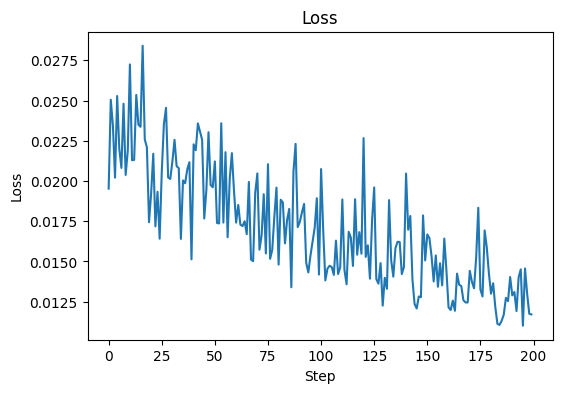

Epoch [551], Loss: 0.0117:  11%|█         | 551/5000 [15:29<1:15:54,  1.02s/it]

In [ ]:
def plot_loss(losses):
    clear_output(wait=True)  # clear the previous plot
    plt.figure(figsize=(6,4))
    plt.plot(losses[-200:])
    plt.title("Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.show()

testable_model, avg_loss = model.grow(
    env=adapt_env,
    epochs=5000,
    learnign_rate=0.0005,
    pool_size=1024,
    loss_callback=plot_loss,
)

In [ ]:

frames = []
for n in range(96*3):
    # Example: list of frames (NumPy arrays)
    frame = testable_model(board)
    frame_np = frame[0,...].permute(1, 2, 0).cpu().detach().numpy()  # (H, W, C)
    frame_np = (frame_np[..., :4] * 255).astype(np.uint8)
